In [25]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

In [26]:
path_single = "../datasets/images/train/image_2000.h5"
path_single_mask = "../datasets/annotations/train/mask_2000.h5"

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.42230782933301864..3.9737369685644146].


ls ['img']
input data shape: (128, 128, 14)
NDVI shape: (128, 128)
f_data shape: (1, 128, 128, 3)
ls ['mask']
mask shape: (128, 128)


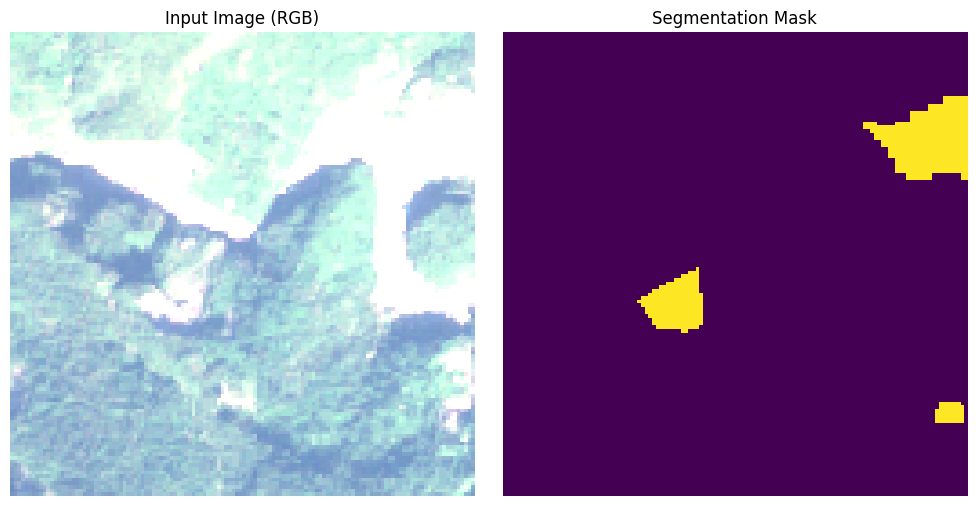

In [27]:
f_data = np.zeros((1, 128, 128, 3))

# Load input image
with h5py.File(path_single) as hdf:
    ls = list(hdf.keys())
    print("ls", ls)
    data = np.array(hdf.get('img'))
    print("input data shape:", data.shape)

    data_red = data[:, :, 3]
    data_green = data[:, :, 2]
    data_blue = data[:, :, 1]
    data_nir = data[:, :, 7]
    data_rgb = data[:, :, 3:0:-1]  # RGB

    data_ndvi = np.divide(data_nir - data_red, np.add(data_nir, data_red) + 1e-6)  # avoid division by zero
    f_data[0, :, :, 0] = data_ndvi
    f_data[0, :, :, 1] = data[:, :, 12]  # slope
    f_data[0, :, :, 2] = data[:, :, 13]  # elevation

    print("NDVI shape:", data_ndvi.shape)
    print("f_data shape:", f_data.shape)

# Load mask
with h5py.File(path_single_mask) as hdf:
    ls = list(hdf.keys())
    print("ls", ls)
    mask = np.array(hdf.get('mask'))
    print("mask shape:", mask.shape)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(data_rgb)
axes[0].set_title("Input Image (RGB)")
axes[0].axis('off')

axes[1].imshow(mask)
axes[1].set_title("Segmentation Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [28]:
import h5py
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

In [29]:
# # Load true mask
# with h5py.File('true_mask_0.h5', 'r') as hdf:
#     true_mask = np.array(hdf['mask'])
#     print("True mask shape:", true_mask.shape)

# # Load predicted mask
# with h5py.File('pred_mask_0.h5', 'r') as hdf:
#     pred_mask = np.array(hdf['mask'])
#     print("Predicted mask shape:", pred_mask.shape)

# # Plot both masks side by side
# plt.figure(figsize=(10, 4))

# plt.subplot(1, 2, 1)
# plt.imshow(true_mask)
# plt.title("Ground Truth Mask")
# plt.axis('off')

# plt.subplot(1, 2, 2)
# plt.imshow(pred_mask)
# plt.title("Predicted Mask")
# plt.axis('off')

# plt.tight_layout()
# plt.show()


In [30]:
def save_mask_to_h5(mask_array, save_path, dataset_name='mask'):
    with h5py.File(save_path, 'w') as f:
        f.create_dataset(dataset_name, data=mask_array, compression='gzip')
    print(f"Mask saved to {save_path}")

True mask shape: (128, 128)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

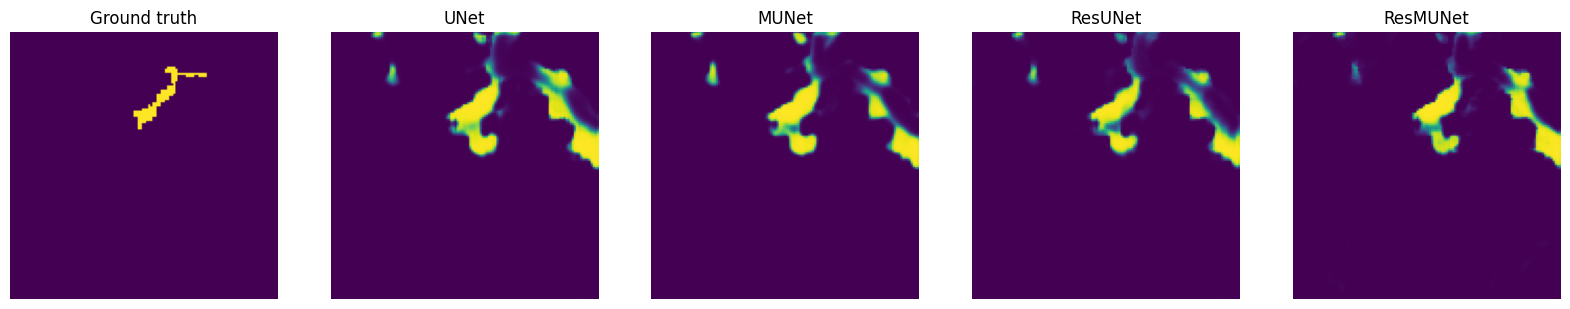

In [31]:
with h5py.File('true_mask_0.h5', 'r') as hdf:
    true_mask = np.array(hdf['mask'])
    print("True mask shape:", true_mask.shape)

with h5py.File('pred_mask_0_UNet.h5', 'r') as hdf:
    pred_mask_1 = np.array(hdf['mask'])
    
with h5py.File('pred_mask_0_MUNet.h5', 'r') as hdf:
    pred_mask_2 = np.array(hdf['mask'])

with h5py.File('pred_mask_0_ResUNet.h5', 'r') as hdf:
    pred_mask_3 = np.array(hdf['mask'])

with h5py.File('pred_mask_0_ResMUNet.h5', 'r') as hdf:
    pred_mask_4 = np.array(hdf['mask'])

plt.figure(figsize=(20,6))

plt.subplot(1,5,1)
plt.imshow(true_mask)
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1,5,2)
plt.imshow(pred_mask_1)
plt.title('UNet')
plt.axis('off')

plt.subplot(1,5,3)
plt.imshow(pred_mask_2)
plt.title('MUNet')
plt.axis('off')

plt.subplot(1,5,4)
plt.imshow(pred_mask_3)
plt.title('ResUNet')
plt.axis('off')

plt.subplot(1,5,5)
plt.imshow(pred_mask_4)
plt.title('ResMUNet')
plt.axis('off')

In [32]:
# # Load ground truth mask from H5
# with h5py.File('true_mask_0.h5', 'r') as f:
#     gt_mask = np.array(f['mask'])

# # Load predicted mask from H5
# with h5py.File('pred_mask_0.h5', 'r') as f:
#     pred_mask = np.array(f['mask'])

# # Ensure both are binary and same shape
# assert gt_mask.shape == pred_mask.shape, "Shape mismatch!"

# gt_mask = gt_mask.astype(bool).flatten()
# pred_mask = (pred_mask>=0.62).astype(bool).flatten()

# print(f"Ground Truth - 1s: {np.sum(gt_mask)}, 0s: {gt_mask.size - np.sum(gt_mask)}")
# print(f"Prediction   - 1s: {np.sum(pred_mask)}, 0s: {pred_mask.size - np.sum(pred_mask)}")

# # Calculate metrics
# precision = precision_score(gt_mask, pred_mask, zero_division=0)
# recall = recall_score(gt_mask, pred_mask, zero_division=0)
# f1 = f1_score(gt_mask, pred_mask, zero_division=0)
# iou = jaccard_score(gt_mask, pred_mask, zero_division=0)

# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"F1-Score:  {f1:.4f}")
# print(f"IoU:       {iou:.4f}")
